# MAU, ARPU and a Loyalty Funnel on Real Online Retail Data

**Product:** Online Retail II (UCI) — real transactions from a UK gift retailer over 2 years (Dec 2009 – Dec 2011), ~800K valid rows after cleaning.

**Product question:** how does the active customer base (MAU) and revenue per user (ARPU) evolve over time, and what role do different purchase-frequency segments play in revenue — to understand where to focus retention efforts.

## 1. Load and clean the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('online_retail_II.csv')
print("raw:", df.shape)
display(df.head(),df.info())

raw: (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


None

In [3]:
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['revenue'] = df['Quantity'] * df['Price']
df['month'] = df['InvoiceDate'].dt.to_period('M')

print("clean:", df.shape)

clean: (805549, 10)


Of 1 067 371 rows, 805 549 remain after removing records with no customer ID, cancelled orders, and invalid prices/quantities.

## 2. MAU and ARPU by month

**MAU** — number of unique customers with a purchase in the month.

**ARPU** — monthly revenue divided by that month's MAU.

In [4]:
monthly = df.groupby('month').agg(    
    mau=('Customer ID','nunique'),    
    revenue=('revenue','sum'),    
    orders=('Invoice','nunique'))

monthly['arpu'] = monthly['revenue'] / monthly['mau']
monthly.head()

,mau,revenue,orders,arpu
month,,,,
2009-12,955,686654.160,1512,719.009592
2010-01,720,557319.062,1011,774.054253
2010-02,772,506371.066,1104,655.921070
2010-03,1057,699608.991,1524,661.881732
2010-04,942,594609.192,1329,631.219949


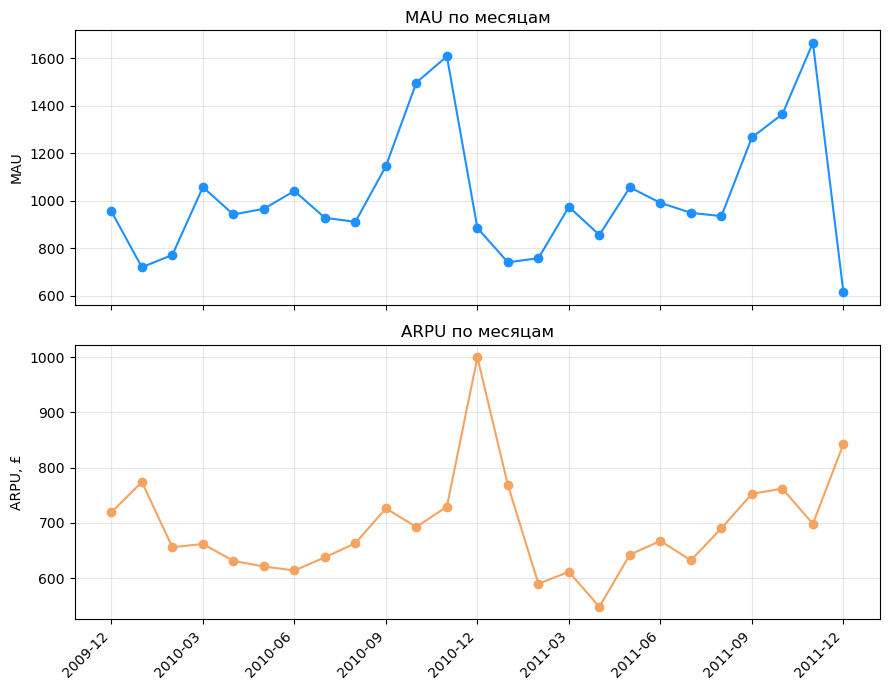

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

x = range(len(monthly))

ax1.plot(x, monthly['mau'], marker='o', color='dodgerblue')
ax1.set_ylabel('MAU')
ax1.set_title('MAU по месяцам')
ax1.grid(alpha=0.3)

ax2.plot(x, monthly['arpu'], marker='o', color='sandybrown')
ax2.set_ylabel('ARPU, £')
ax2.set_title('ARPU по месяцам')
ax2.set_xticks(list(x)[::3])
ax2.set_xticklabels(monthly.index.astype(str)[::3], rotation=45, ha='right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:** MAU rises toward November (a pre-Christmas seasonal peak — 1,664 customers in November 2011, nearly double the baseline of ~900-1,000), then drops sharply in December — but this is a **data artifact**, not a real decline: the last month is truncated at December 9, 2011, not the full month. It's important to always check period completeness before flagging a "drop" to the product team — otherwise you risk a false alarm.ARPU is volatile and doesn't track MAU growth — the most notable spike (£1,000) is in December 2010.

### Checking: what actually drove the December 2010 ARPU spike

ARPU can be decomposed into two parts: **(orders per customer) × (revenue per order)**. Let's check which one increased.

In [6]:
monthly['orders_per_mau'] = monthly['orders'] / monthly['mau']
monthly['revenue_per_order'] = monthly['revenue'] / monthly['orders']
monthly.loc[['2010-11','2010-12','2011-01'], ['arpu','orders_per_mau','revenue_per_order']]

,arpu,orders_per_mau,revenue_per_order
month,,,
2010-11,729.518383,1.609832,453.164299
2010-12,999.538859,1.581921,631.851350
2011-01,768.481835,1.331984,576.945329


Orders per customer in December 2010 did **not** increase (1.58, in line with other months) — the entire ARPU rise comes from revenue per order (£632 vs £453 in November). So customers weren't ordering more often, individual orders got more expensive. Let's check whether this is driven by a handful of abnormally large orders, or a broad shift across the whole distribution.

In [7]:
dec2010 = df[df['month'] == pd.Period('2010-12')]
by_invoice = dec2010.groupby('Invoice')['revenue'].sum().sort_values(ascending=False)
mau_dec = dec2010['Customer ID'].nunique()
full_arpu = by_invoice.sum() / mau_dec

for k in [5, 10, 50]:
    arpu_excl = by_invoice.iloc[k:].sum() / mau_dec
    print(f"ARPU без топ-{k} заказов: £{arpu_excl:.0f} (было £{full_arpu:.0f})")

nov2010 = df[df['month'] == pd.Period('2010-11')]
by_invoice_nov = nov2010.groupby('Invoice')['revenue'].sum()

print()
print(f"Медиана заказа: декабрь 2010 = £{by_invoice.median():.0f}, ноябрь 2010 = £{by_invoice_nov.median():.0f}")

ARPU без топ-5 заказов: £914 (было £1000)
ARPU без топ-10 заказов: £881 (было £1000)
ARPU без топ-50 заказов: £721 (было £1000)

Медиана заказа: декабрь 2010 = £363, ноябрь 2010 = £301


**Conclusion after checking:** a handful of large orders explain only part of the effect (excluding the top 50 of 1,400 orders only brings ARPU down ~28%, to £721 — still above the normal baseline). The larger driver is a **broad shift of the entire order-value distribution toward higher values**: even the median (typical) order in December 2010 is 21% more expensive than in November (£363 vs £301). This looks like a pre-holiday effect of generally larger purchases, not 2-3 outlier customers.

## 3. Loyalty funnel: New → Returning → Loyal

This dataset has no step-level events (view/cart/purchase), so the funnel is built on purchase frequency per customer:
- **New** — 1 order total
- **Returning** — 2-3 orders
- **Loyal** — 4+ orders

In [8]:
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique()

def segment(n):
    if n == 1:
        return 'New (1 order)'
    elif n <= 3:
        return 'Returning (2-3 orders)'
    else:
        return 'Loyal (4+ orders)'

seg = orders_per_customer.apply(segment)

funnel = seg.value_counts().reindex([
    'New (1 order)',
    'Returning (2-3 orders)',
    'Loyal (4+ orders)'
])

print(funnel)
print((funnel / funnel.sum() * 100).round(1))

Invoice
New (1 order)             1623
Returning (2-3 orders)    1608
Loyal (4+ orders)         2647
Name: count, dtype: int64
Invoice
New (1 order)             27.6
Returning (2-3 orders)    27.4
Loyal (4+ orders)         45.0
Name: count, dtype: float64


In [9]:
cust_revenue = df.groupby('Customer ID')['revenue'].sum()
cust_df = pd.DataFrame({'orders': orders_per_customer, 'segment': seg, 'revenue': cust_revenue})
rev_by_seg = cust_df.groupby('segment')['revenue'].agg(['count','sum','mean']).reindex(    ['New (1 order)','Returning (2-3 orders)','Loyal (4+ orders)'])

print(rev_by_seg)
print((rev_by_seg['sum']/rev_by_seg['sum'].sum()*100).round(1))

                        count           sum         mean
segment                                                 
New (1 order)            1623  5.681738e+05   350.076298
Returning (2-3 orders)   1608  1.622596e+06  1009.077129
Loyal (4+ orders)        2647  1.555266e+07  5875.579646
segment
New (1 order)              3.2
Returning (2-3 orders)     9.1
Loyal (4+ orders)         87.7
Name: sum, dtype: float64


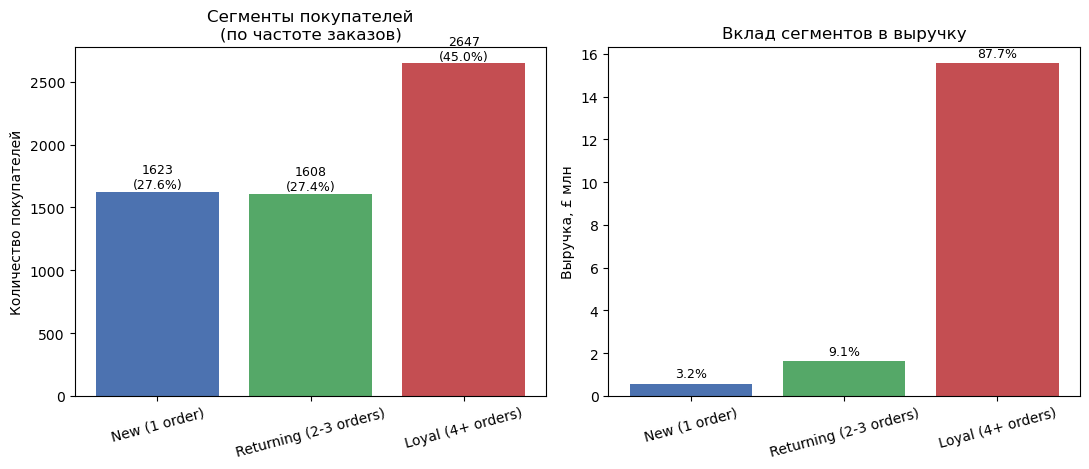

In [10]:
order = ['New (1 order)', 'Returning (2-3 orders)', 'Loyal (4+ orders)']
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))

ax1.bar(order, funnel.values, color=colors)
ax1.set_ylabel('Количество покупателей')
ax1.set_title('Сегменты покупателей\n(по частоте заказов)')
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(funnel.values):
    ax1.text(i, v + 30, f"{v}\n({v / funnel.sum() * 100:.1f}%)", ha='center', fontsize=9)

ax2.bar(order, rev_by_seg['sum'].values / 1e6, color=colors)
ax2.set_ylabel('Выручка, £ млн')
ax2.set_title('Вклад сегментов в выручку')
ax2.tick_params(axis='x', rotation=15)
for i, v in enumerate(rev_by_seg['sum'].values):
    ax2.text(i, v / 1e6 + 0.3, f"{v / rev_by_seg['sum'].sum() * 100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Key insight:** 45% of customers (Loyal) generate **87.7% of total revenue**, while New customers (27.6% of the base) contribute only 3.2%. This is a classic Pareto concentration in retail — and a risk signal: the business depends heavily on a relatively small group of repeat customers. The product recommendation is to not spread the retention budget evenly across all segments, but focus retention mechanics on converting Returning → Loyal, since that transition drives the largest LTV gain.

## 4. Bonus: cohort retention

For each customer, we identify their first-purchase month (cohort) and track what share of the cohort keeps buying in subsequent months.

In [11]:
df['order_month'] = df['InvoiceDate'].dt.to_period('M')
first_purchase = df.groupby('Customer ID')['order_month'].min().rename('cohort_month')
df = df.merge(first_purchase, on='Customer ID')
df['period_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)
cohort_pivot = df.groupby(['cohort_month','period_number'])['Customer ID'].nunique().reset_index().pivot(  
    index='cohort_month', columns='period_number', values='Customer ID')
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)
avg_retention = retention.iloc[:-1, :7].mean() 
print((avg_retention*100).round(1))

period_number
0    100.0
1     21.2
2     21.9
3     21.6
4     20.5
5     18.8
6     17.8
dtype: float64


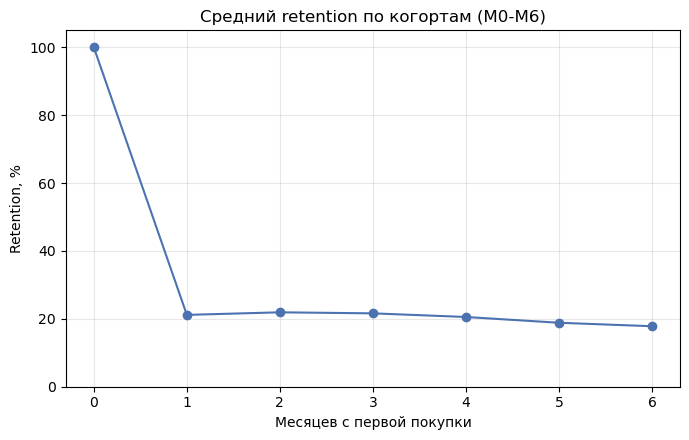

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(avg_retention.index, avg_retention.values * 100, marker='o', color='#4C72B0')

ax.set_xlabel('Месяцев с первой покупки')
ax.set_ylabel('Retention, %')
ax.set_title('Средний retention по когортам (M0-M6)')
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The sharp drop from 100% to ~21% at M1 is typical for non-subscription retail: most customers don't return the following month, but those who do stabilize around 18-22% for many months after — this is the core of the Loyal segment from the funnel above.

## 5. Conclusion and recommendation

- **MAU** averages around ~1,000 customers/month with a clear pre-Christmas seasonal peak (+65% over baseline)
- **ARPU** is volatile and driven mainly by large wholesale orders, not a broad increase in average order value- **45% of customers (Loyal) generate 87.7% of revenue** — a strong concentration; the business depends on a narrow segment
- **Retention drops from 100% to ~21% within the first month** and holds around that level afterward — the retention window for a new customer is very short

**Recommendation to the product team:** prioritize retention mechanics (email re-engagement, personalized offers) specifically within the first month after a customer's first purchase — that's where the largest share of future Loyal customers is lost — rather than spreading the retention budget evenly across the whole base.